In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv
from src.utils import *

load_dotenv()

True

In [2]:
DATA_DIR = os.getenv("DATA_FOLDER")
RESULTS_DIR = "data"

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "sbod_data_cleaned.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           161028 non-null  int64
 1   Cause          161028 non-null  str  
 2   Location       161028 non-null  str  
 3   Age            161028 non-null  str  
 4   Sex            161028 non-null  str  
 5   RAG            161028 non-null  str  
 6   Measure        161028 non-null  str  
 7   Value          161028 non-null  str  
 8   Small numbers  161028 non-null  str  
dtypes: int64(1), str(8)
memory usage: 11.1 MB


In [4]:
all_locations = df["Location"].unique().tolist()

In [5]:
dfs = {}

for loc in tqdm(all_locations):
    if loc == "Scotland":
        continue
    file = f"{loc.replace(' ', '_').lower()}_analysis.xlsx"
    f_df = pd.read_excel(os.path.join(RESULTS_DIR, file), sheet_name="Female")
    m_df = pd.read_excel(os.path.join(RESULTS_DIR, file), sheet_name="Male")

    cols = ["Cause", "Scotland_2019"] + [f"{loc}_{yr}" for yr in range(2014, 2020)]
    f_df = f_df[cols]
    m_df = m_df[cols]
    dfs[loc] = {"Male": m_df, "Female": f_df}

100%|██████████| 18/18 [00:00<00:00, 22.00it/s]


In [6]:
dfs["East Scotland"]["Male"]

,Cause,Scotland_2019,East Scotland_2014,East Scotland_2015,East Scotland_2016,East Scotland_2017,East Scotland_2018,East Scotland_2019
0,Ischaemic heart disease,3713,3800,3862,3622,3727,3422,3248
1,Drug use disorders,2367,1138,1174,1301,1546,1774,1766
2,Lung cancer,1749,1977,1834,1750,1772,1581,1668
3,Alzheimer's disease and other dementias,1639,1364,1632,1528,1740,1620,1622
4,Cerebrovascular disease,1516,1604,1564,1589,1595,1488,1450
...,...,...,...,...,...,...,...,...
65,Breast cancer,15,15,8,14,14,14,20
66,Other diabetes and chronic kidney disorders,4,0,1,4,0,0,0
67,Gynecological diseases,1,1,1,1,1,1,1
68,Maternal disorders,0,0,0,0,0,0,0


We calculate growth rates using data from `2014` to a chosen `end_yr`, then predict `end_yr + 1` and evaluate predictive performance across locations and sexes.

Methods included:
- CAGR
- LAGR
- TSQ2 (mean, median, interval, base)
- TSQ3 (mean, median, interval, base)

The workflow below is modular so we can reuse the exact same pipeline for different `end_yr` values (for example, `2018` and `2017`) and compare heatmaps consistently.

In [12]:
NORM_MODES = ["mean", "median", "interval", "base"]
Q_VALUES = (2, 3)


def get_accuracy(preds, actuals):
    ss_res = np.sum((preds - actuals) ** 2)
    ss_tot = np.sum((actuals - np.mean(actuals)) ** 2)
    return 1 - (ss_res / ss_tot)

def get_rmsle(preds, actuals):
    """
    Calculates the Root Mean Squared Logarithmic Error (RMSLE) between predictions and actual values.
    Formula: RMSLE = sqrt(mean((log(preds + 1) - log(actuals + 1))^2))
    """
    return np.sqrt(np.mean((np.log1p(preds) - np.log1p(actuals)) ** 2))


def get_lagr(row, loc, start_yr, end_yr):
    return ((row[f"{loc}_{end_yr}"] - row[f"{loc}_{start_yr}"]) / (1e-4 + row[f"{loc}_{start_yr}"])) * 100


def add_growth_predictions(df, loc, start_yr, end_yr, norm_modes=NORM_MODES, q_values=Q_VALUES):
    base_col = f"{loc}_{end_yr}"

    cagr_col = f"{loc}_CAGR_{start_yr}_{end_yr}"
    cagr_pred_col = f"{loc}_{end_yr + 1}_pred_CAGR"
    df[cagr_col] = df.apply(lambda row: get_cagr(row, loc, start_yr, end_yr), axis=1)
    df[cagr_pred_col] = df.apply(
        lambda row: (1 + (row[cagr_col] / 100)) * row[base_col],
        axis=1
    )

    lagr_col = f"{loc}_LAGR_{end_yr - 1}_{end_yr}"
    lagr_pred_col = f"{loc}_{end_yr + 1}_pred_LAGR"
    df[lagr_col] = df.apply(lambda row: get_lagr(row, loc, end_yr - 1, end_yr), axis=1)
    df[lagr_pred_col] = df.apply(
        lambda row: (1 + (row[lagr_col] / 100)) * row[base_col],
        axis=1
    )

    years = list(range(start_yr, end_yr + 1))
    for q in q_values:
        for norm_mode in norm_modes:
            tsq_col = f"{loc}_tsq{q}_{norm_mode}_{start_yr}_{end_yr}"
            pred_col = f"{loc}_{end_yr + 1}_pred_tsq{q}_{norm_mode}"
            df[tsq_col] = df.apply(
                lambda row: get_tsq(
                    years,
                    [row[f"{loc}_{yr}"] for yr in years],
                    q=q,
                    norm_mode=norm_mode
                ),
                axis=1
            )
            df[pred_col] = df.apply(
                lambda row: (1 + (row[tsq_col] / 100)) * row[base_col],
                axis=1
            )

    return df

def evaluate_predictions(modeled_df, end_yr, norm_modes=NORM_MODES, q_values=Q_VALUES):
    accuracy_data = []
    for loc, df_dict in modeled_df.items():
        for sex, df in df_dict.items():
            target_col = f"{loc}_{end_yr + 1}"
            accuracy_row = {"Location": loc, "Sex": sex}
            accuracy_row["Baseline"] = get_accuracy(df[f"{loc}_{end_yr}"], df[target_col]) # Baseline accuracy using last known year
            accuracy_row["CAGR"] = get_accuracy(df[f"{loc}_{end_yr + 1}_pred_CAGR"], df[target_col])
            accuracy_row["LAGR"] = get_accuracy(df[f"{loc}_{end_yr + 1}_pred_LAGR"], df[target_col])
            for norm_mode in norm_modes:
                accuracy_row[f"TSQ2_{norm_mode}"] = get_accuracy(
                    df[f"{loc}_{end_yr + 1}_pred_tsq2_{norm_mode}"],
                    df[target_col]
                )
            for norm_mode in norm_modes:
                accuracy_row[f"TSQ3_{norm_mode}"] = get_accuracy(
                    df[f"{loc}_{end_yr + 1}_pred_tsq3_{norm_mode}"],
                    df[target_col]
                )
            accuracy_data.append(accuracy_row)

    accuracy_df = pd.DataFrame(accuracy_data)

    # RMSLE Evaluation
    rmsle_data = []
    for loc, df_dict in modeled_df.items():
        for sex, df in df_dict.items():
            target_col = f"{loc}_{end_yr + 1}"
            rmsle_row = {"Location": loc, "Sex": sex}
            rmsle_row["Baseline"] = get_rmsle(df[f"{loc}_{end_yr}"], df[target_col])
            rmsle_row["CAGR"] = get_rmsle(df[f"{loc}_{end_yr + 1}_pred_CAGR"], df[target_col])
            rmsle_row["LAGR"] = get_rmsle(df[f"{loc}_{end_yr + 1}_pred_LAGR"], df[target_col])
            for norm_mode in norm_modes:
                rmsle_row[f"TSQ2_{norm_mode}"] = get_rmsle(
                    df[f"{loc}_{end_yr + 1}_pred_tsq2_{norm_mode}"],
                    df[target_col]
                )
            for norm_mode in norm_modes:
                rmsle_row[f"TSQ3_{norm_mode}"] = get_rmsle(
                    df[f"{loc}_{end_yr + 1}_pred_tsq3_{norm_mode}"],
                    df[target_col]
                )
            rmsle_data.append(rmsle_row)

    rmsle_df = pd.DataFrame(rmsle_data)

    return accuracy_df, rmsle_df


def run_growth_pipeline(dfs_source, start_yr, end_yr, norm_modes=NORM_MODES, q_values=Q_VALUES):
    modeled = {}
    for loc, df_dict in dfs_source.items():
        modeled[loc] = {}
        for sex, df in df_dict.items():
            modeled_df = df.copy(deep=True)
            modeled_df = add_growth_predictions(
                modeled_df,
                loc=loc,
                start_yr=start_yr,
                end_yr=end_yr,
                norm_modes=norm_modes,
                q_values=q_values
            )
            modeled[loc][sex] = modeled_df
    
    accuracy_df, rmsle_df = evaluate_predictions(modeled, end_yr=end_yr, norm_modes=norm_modes, q_values=q_values)
    
    return modeled, accuracy_df, rmsle_df


def plot_accuracy_heatmap(accuracy_df, title):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)
    for ax, sex in zip(axes, ["Male", "Female"]):
        subset = accuracy_df[accuracy_df["Sex"] == sex].set_index("Location").drop(columns=["Sex"])
        sns.heatmap(
            subset,
            annot=True,
            cmap="coolwarm",
            vmin=0,
            vmax=1,
            ax=ax,
            cbar=(sex == "Female")
        )
        ax.set_title(sex)
        ax.set_xlabel("Method")
        ax.set_ylabel("Location" if sex == "Male" else "")
    fig.suptitle(title, y=1.02)
    plt.show()


def plot_comparison_heatmap(accuracy_df, norm_modes=NORM_MODES, title="Prediction Accuracy Difference by Method"):
    comparison_df = accuracy_df.copy()
    comparison_df["CAGR-Baseline"] = (comparison_df["CAGR"] - comparison_df["Baseline"]).round(2)
    comparison_df["LAGR-Baseline"] = (comparison_df["LAGR"] - comparison_df["Baseline"]).round(2)
    comparison_df["CAGR-LAGR"] = (comparison_df["CAGR"] - comparison_df["LAGR"]).round(2)
    for norm_mode in norm_modes:
        comparison_df[f"TSQ2_{norm_mode}-CAGR"] = (
            comparison_df[f"TSQ2_{norm_mode}"] - comparison_df["CAGR"]
        ).round(2)
        comparison_df[f"TSQ2_{norm_mode}-Baseline"] = (
            comparison_df[f"TSQ2_{norm_mode}"] - comparison_df["Baseline"]
        ).round(2)

    cols = ["Location", "CAGR-LAGR", "CAGR-Baseline", "LAGR-Baseline"] + [f"TSQ2_{norm_mode}-CAGR" for norm_mode in norm_modes] + [f"TSQ2_{norm_mode}-Baseline" for norm_mode in norm_modes]
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)
    for ax, sex in zip(axes, ["Male", "Female"]):
        subset = comparison_df[comparison_df["Sex"] == sex][cols].set_index("Location")
        sns.heatmap(
            subset,
            annot=True,
            cmap=plt.get_cmap("coolwarm_r"),
            center=0,
            vmin=-0.1,
            vmax=0.1,
            ax=ax,
            cbar=(sex == "Female")
        )
        ax.set_title(sex)
        ax.set_xlabel("Comparison")
        ax.set_ylabel("Location" if sex == "Male" else "")
    fig.suptitle(title, y=1.02)
    plt.show()
    return comparison_df

In [8]:
# Run pipeline with training window 2014-2018, predict 2019
end_yr = 2018
dfs1, accuracy_df, rmsle_df = run_growth_pipeline(dfs_source=dfs, start_yr=2014, end_yr=end_yr)

/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


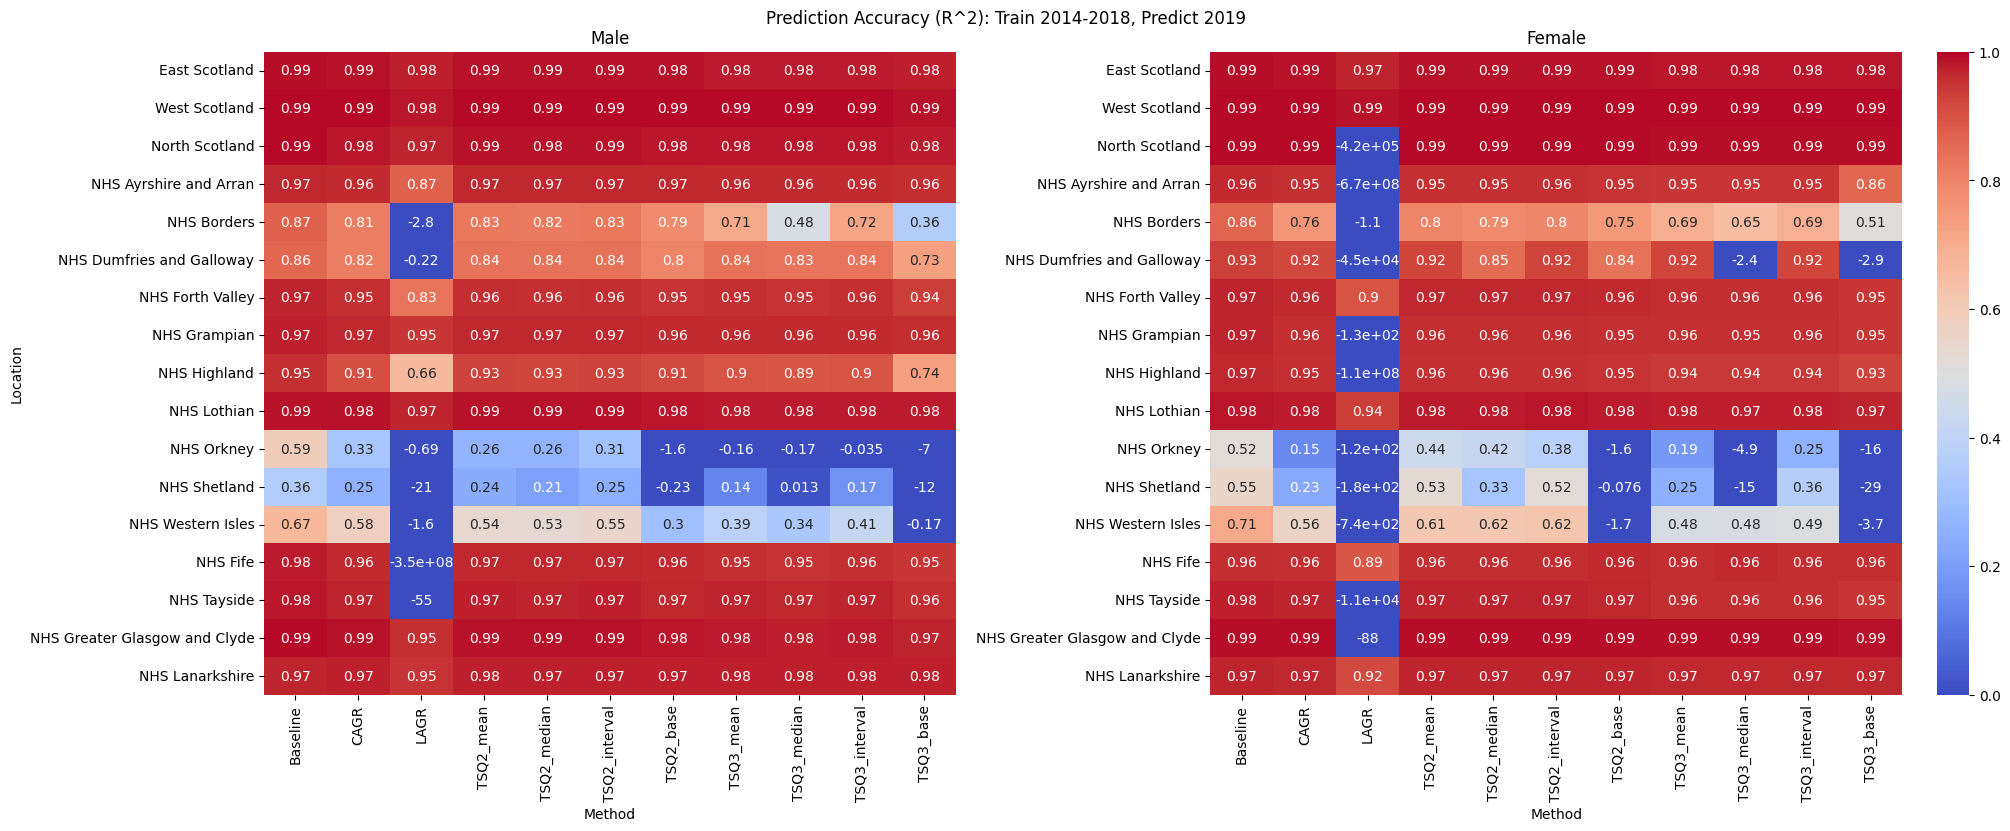

In [9]:
plot_accuracy_heatmap(
    accuracy_df,
    title=f"Prediction Accuracy (R^2): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

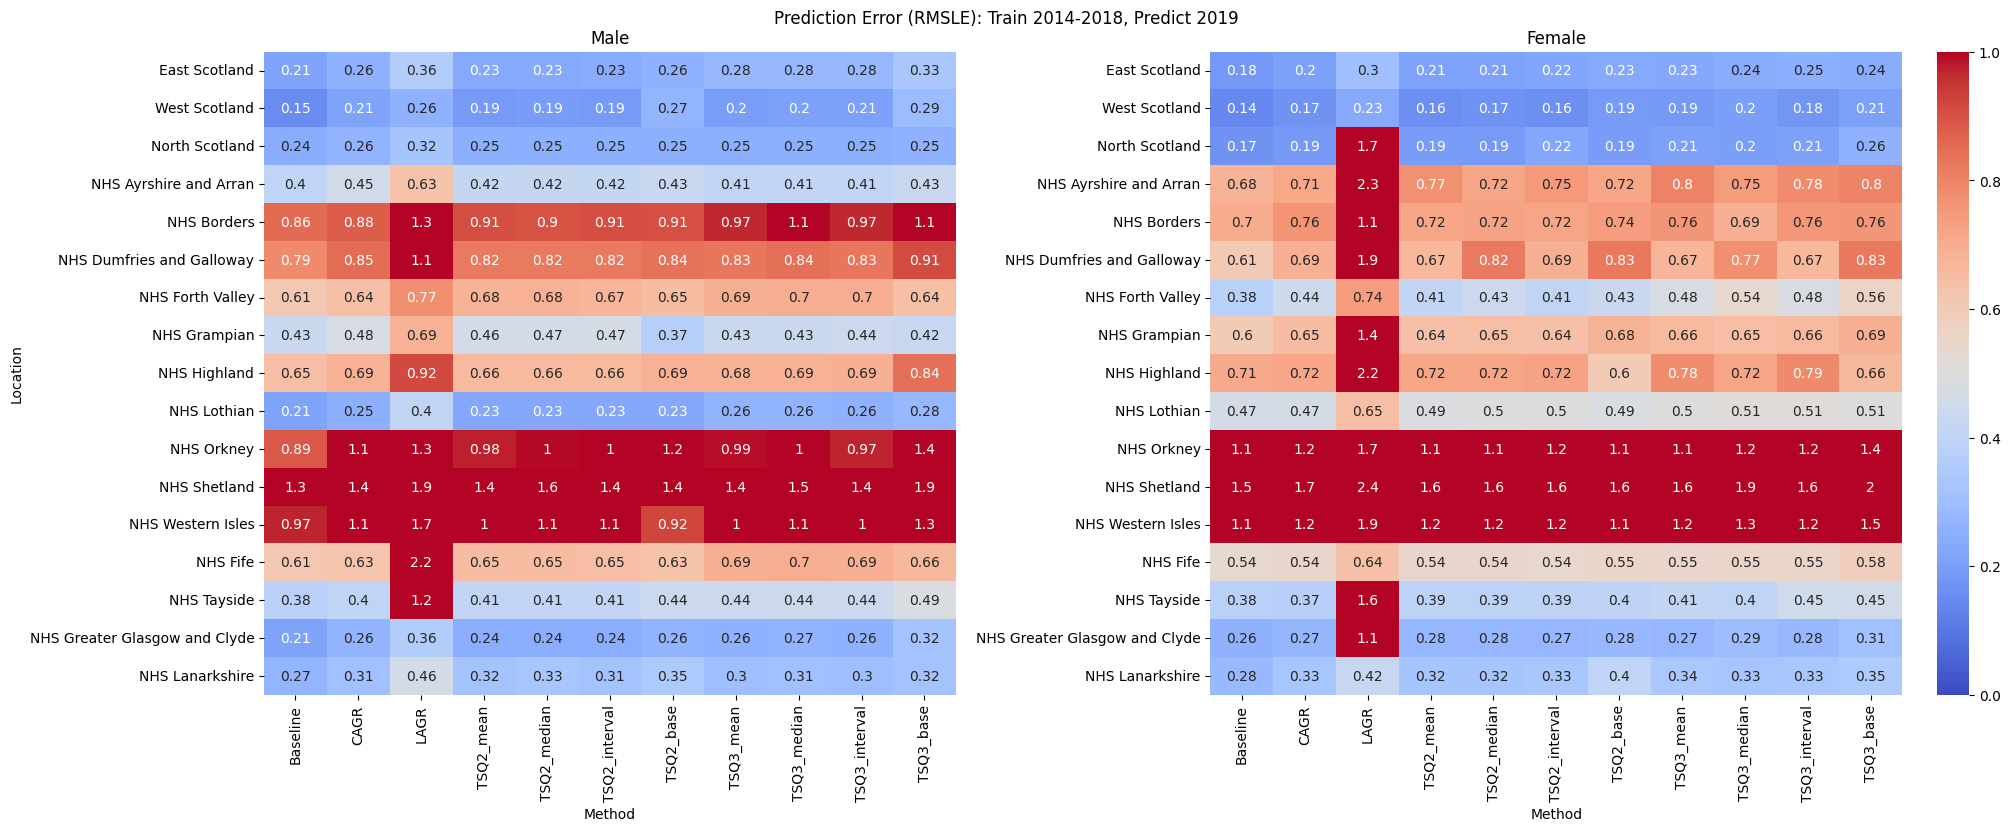

In [10]:
plot_accuracy_heatmap(
    rmsle_df,
    title=f"Prediction Error (RMSLE): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

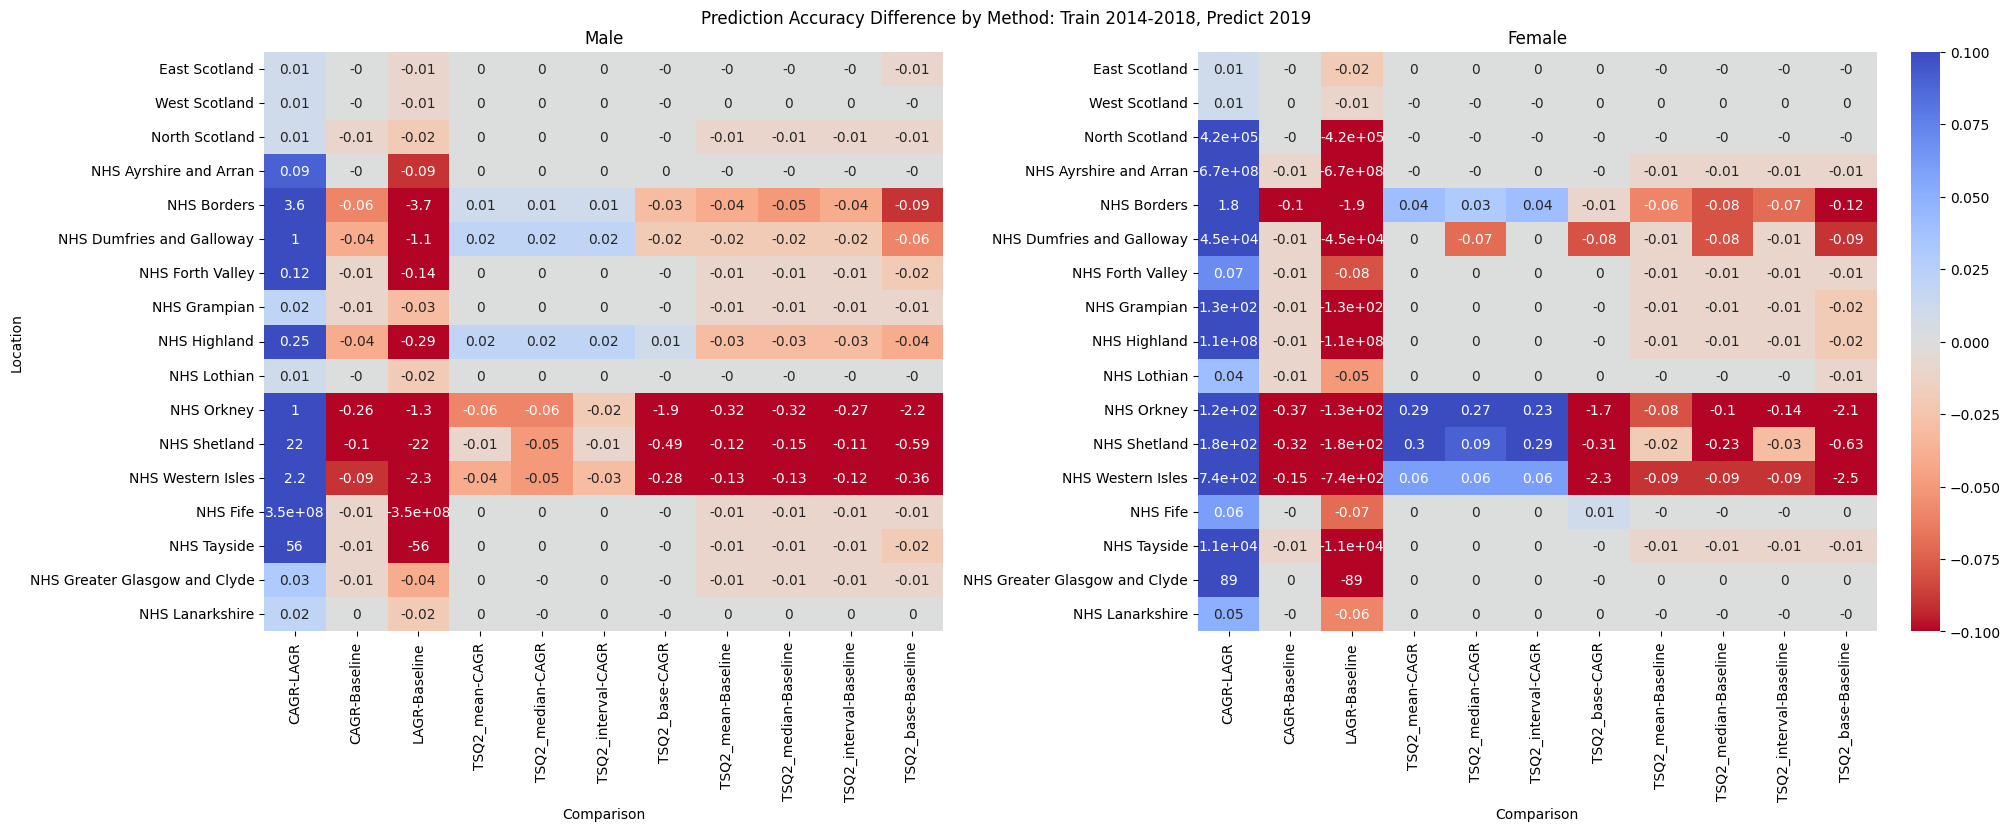

In [13]:
accuracy_comp_2018 = plot_comparison_heatmap(
    accuracy_df,
    title=f"Prediction Accuracy Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)

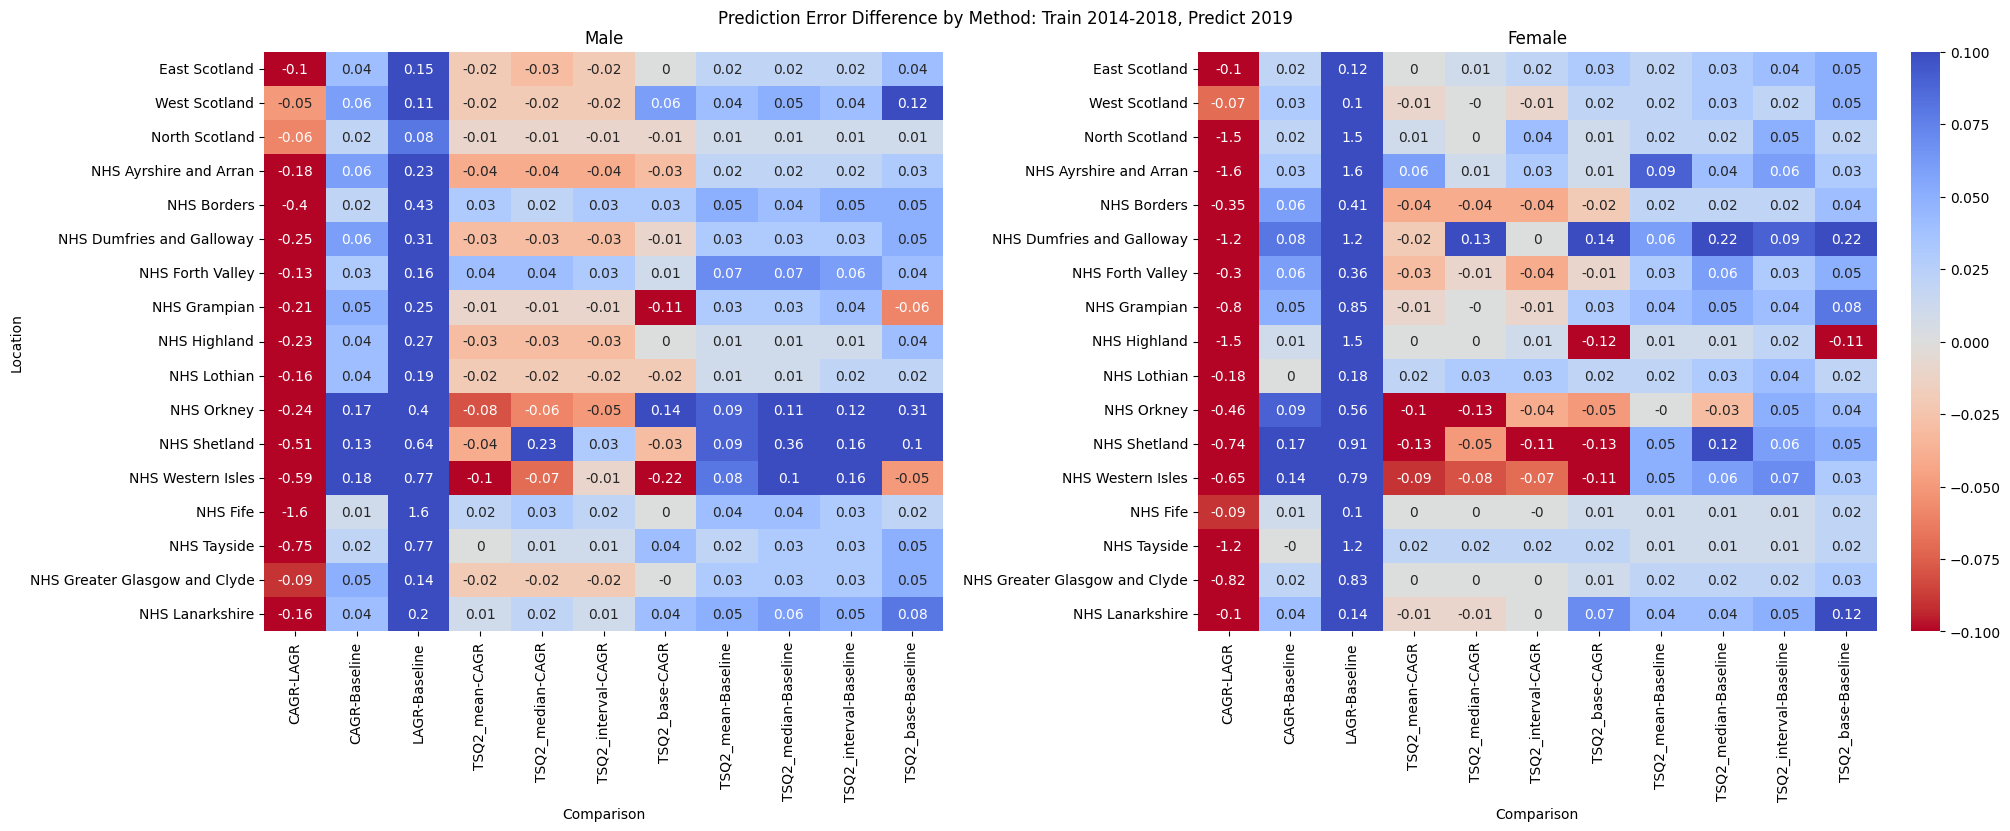

In [15]:
rmsle_comp_2018 = plot_comparison_heatmap(
    rmsle_df,
    title=f"Prediction Error Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)

### 2014-2017

In [16]:
# Run pipeline with training window 2014-2018, predict 2019
end_yr = 2017
dfs1, accuracy_df, rmsle_df = run_growth_pipeline(dfs_source=dfs, start_yr=2014, end_yr=end_yr)

/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


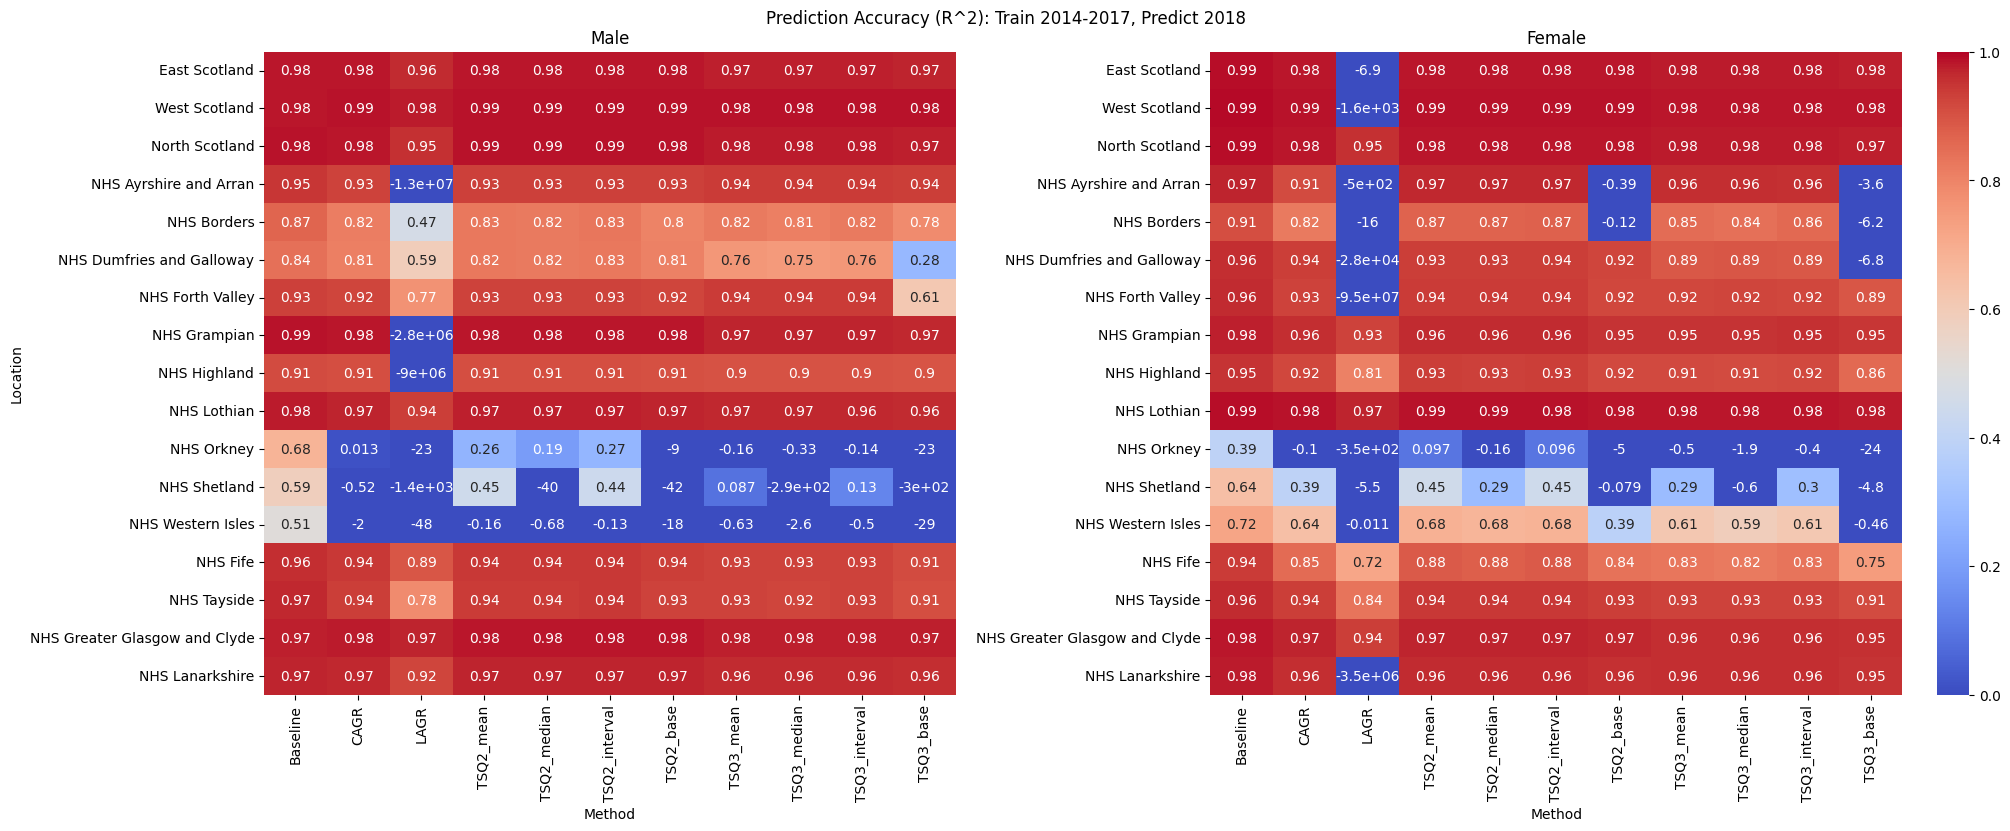

In [17]:
plot_accuracy_heatmap(
    accuracy_df,
    title=f"Prediction Accuracy (R^2): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

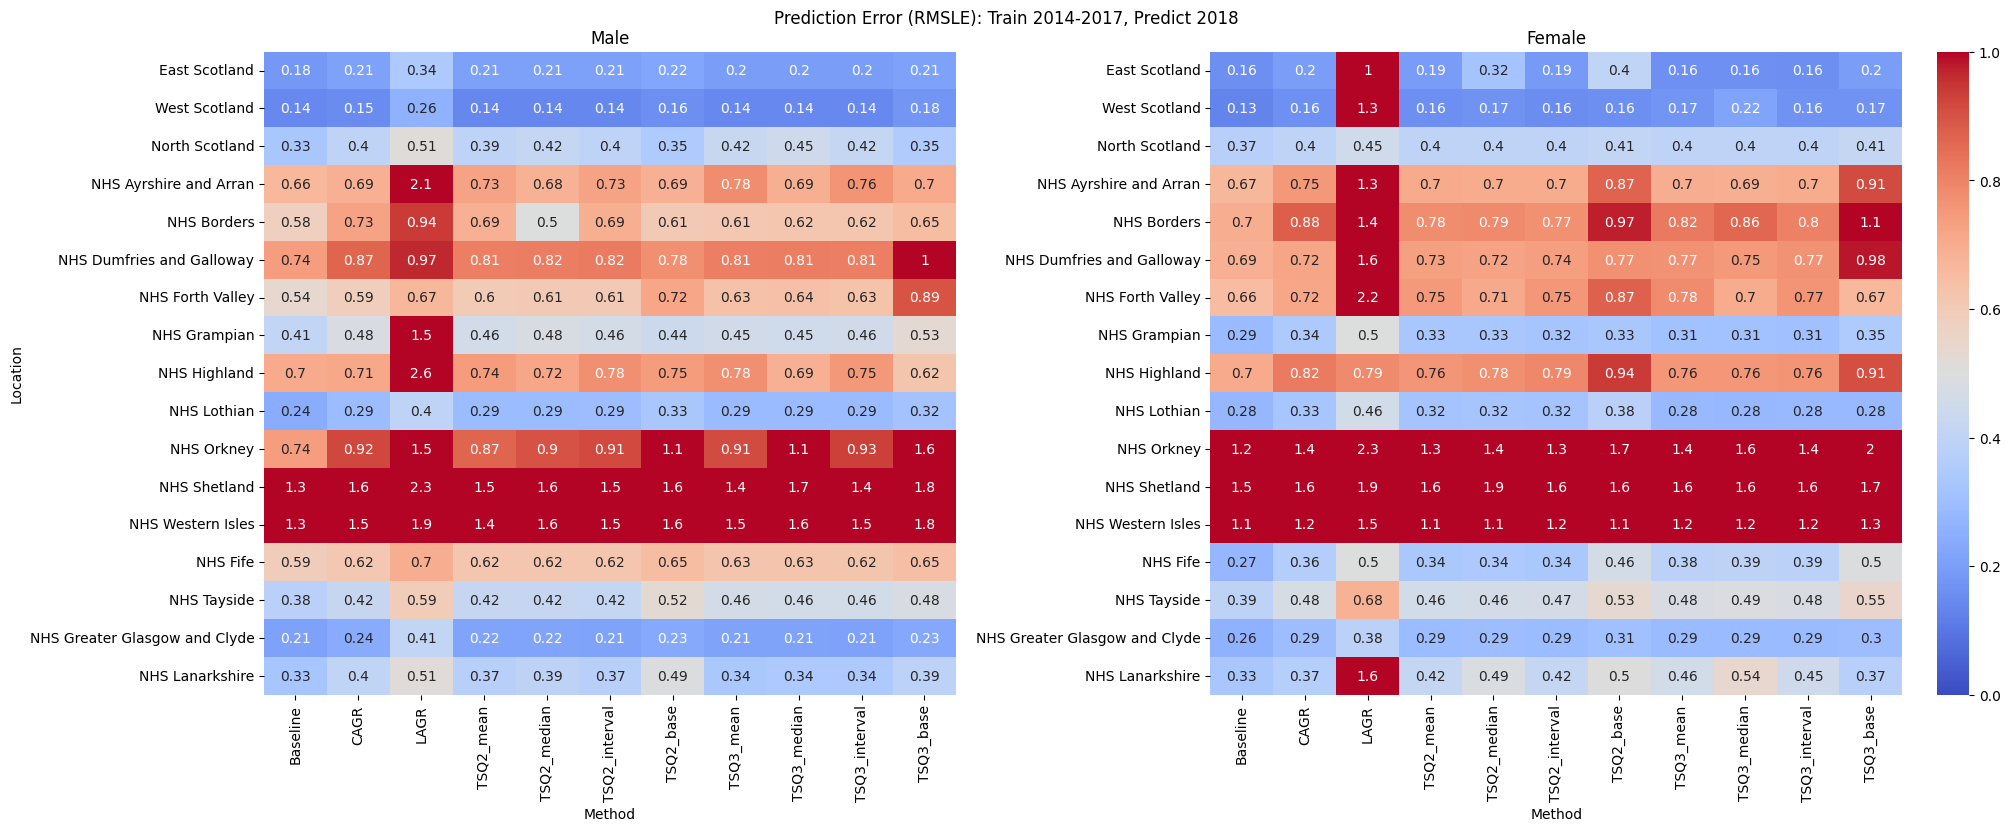

In [19]:
plot_accuracy_heatmap(
    rmsle_df,
    title=f"Prediction Error (RMSLE): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

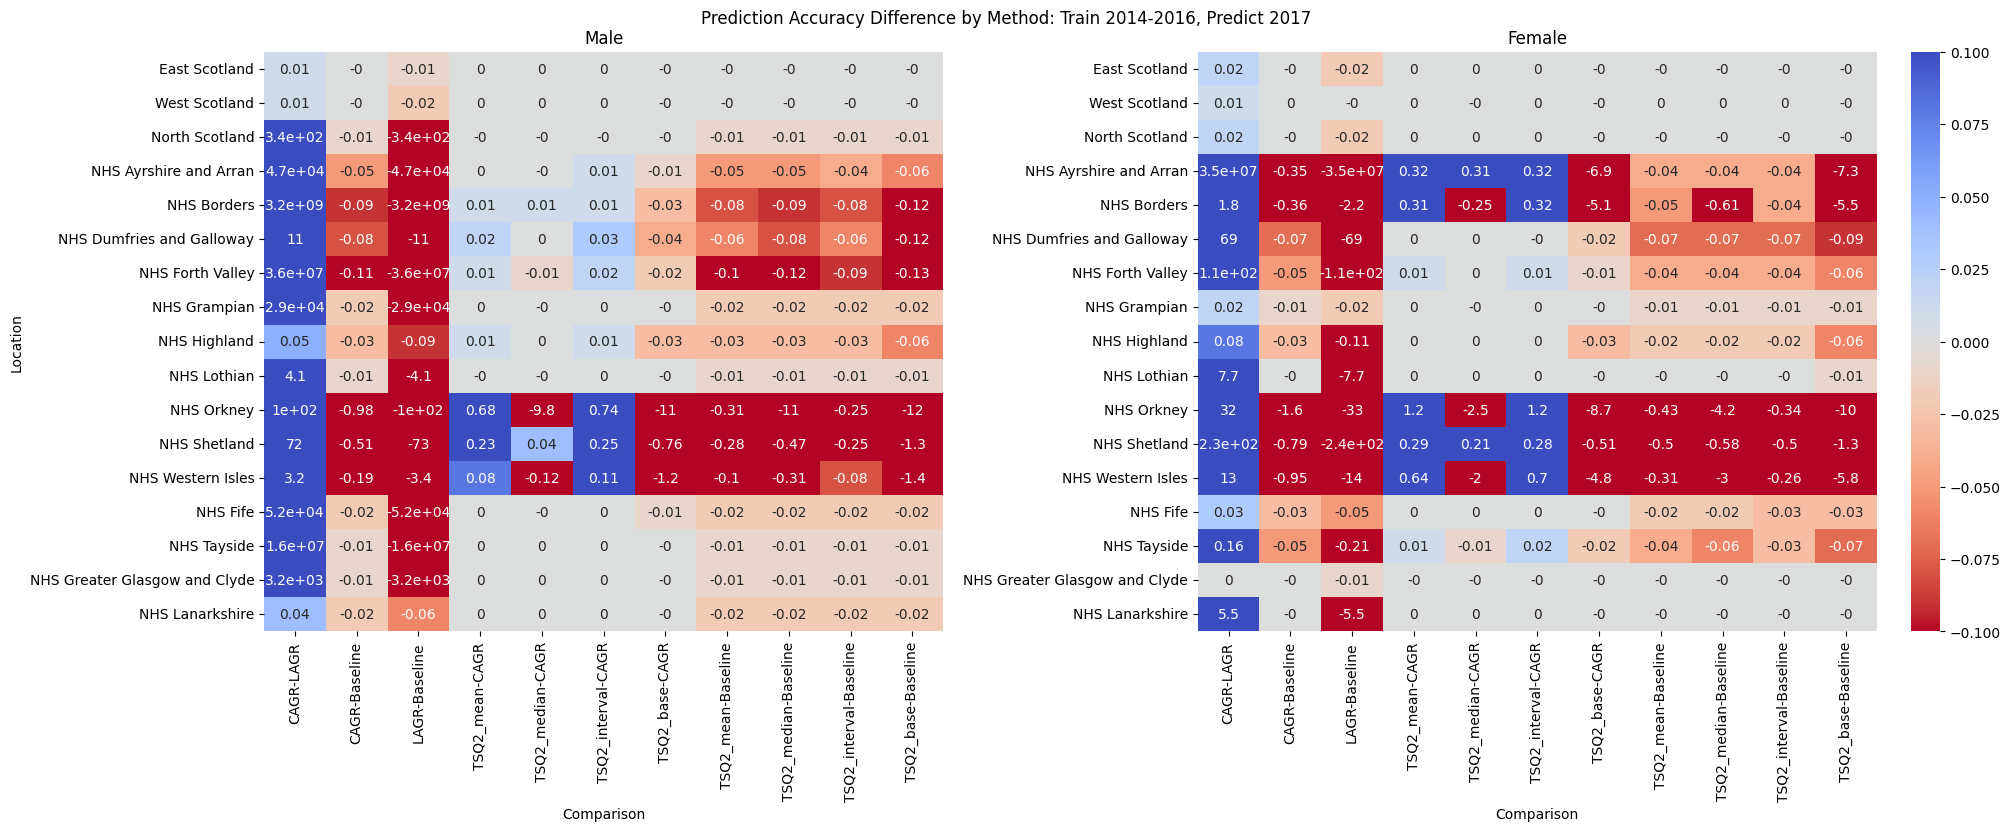

In [21]:
accuracy_comp_2017 = plot_comparison_heatmap(
    accuracy_df,
    title=f"Prediction Accuracy Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)

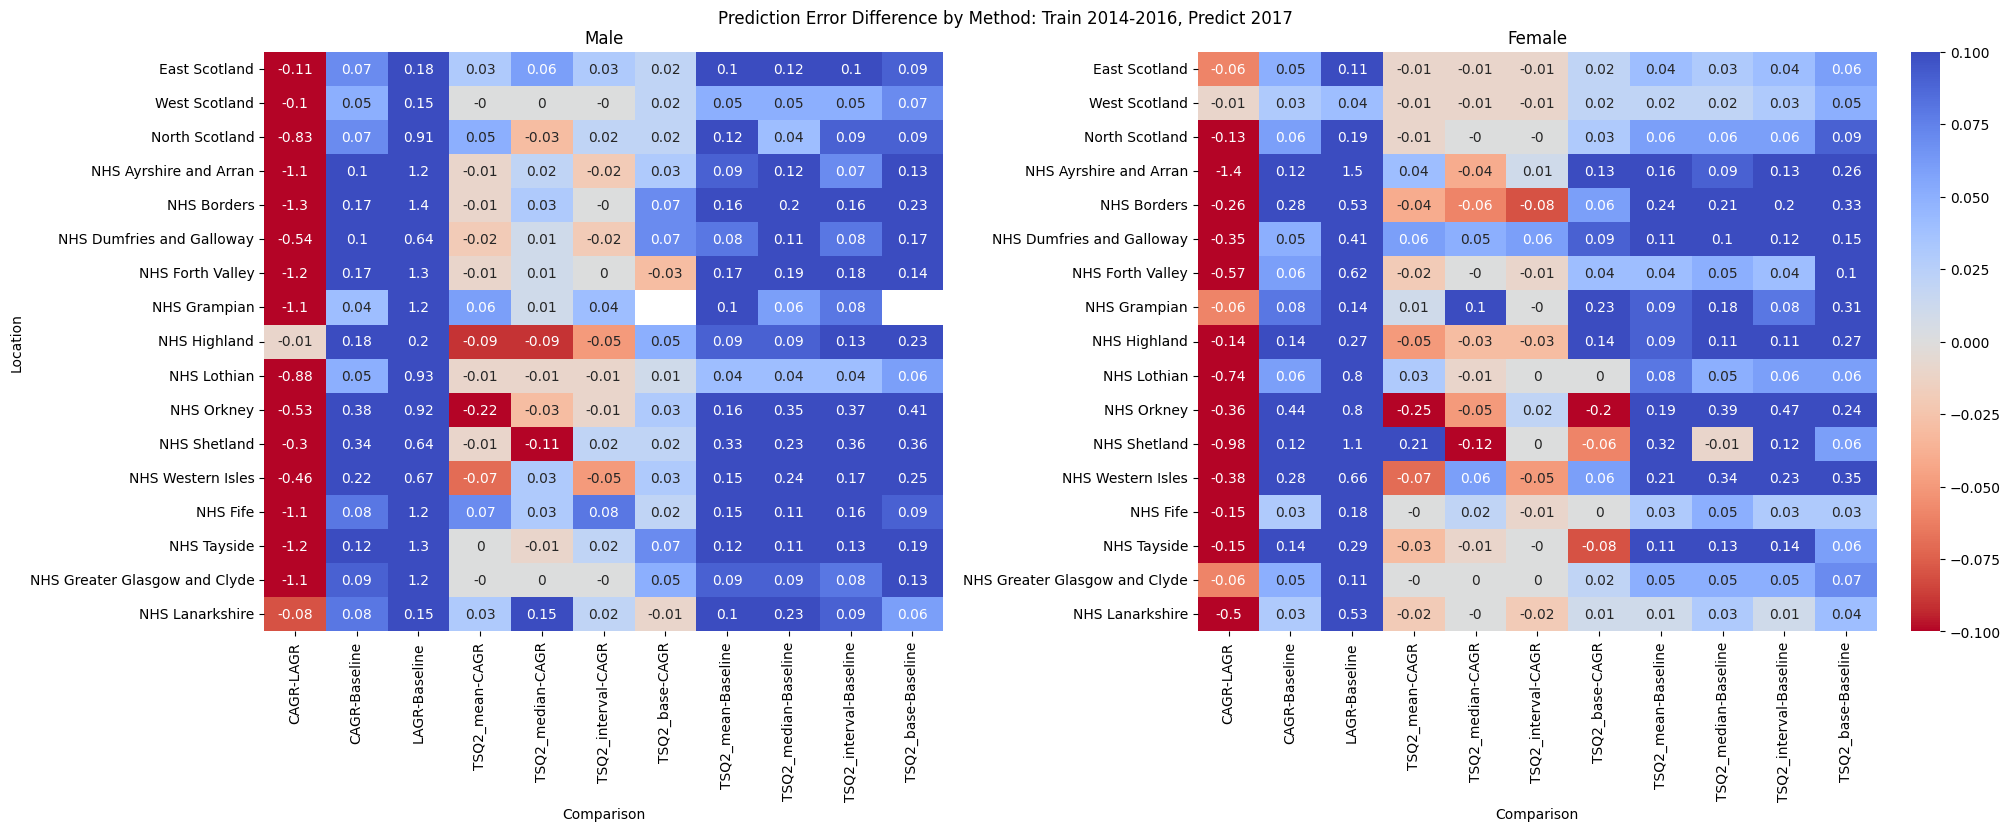

In [22]:
rmsle_comp_2017 = plot_comparison_heatmap(
    rmsle_df,
    title=f"Prediction Error Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)

### 2014-2016

In [20]:
# Run pipeline with training window 2014-2018, predict 2019
end_yr = 2016
dfs1, accuracy_df, rmsle_df = run_growth_pipeline(dfs_source=dfs, start_yr=2014, end_yr=end_yr)

/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/asudarshan14/Scotland_BOD/gbd/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


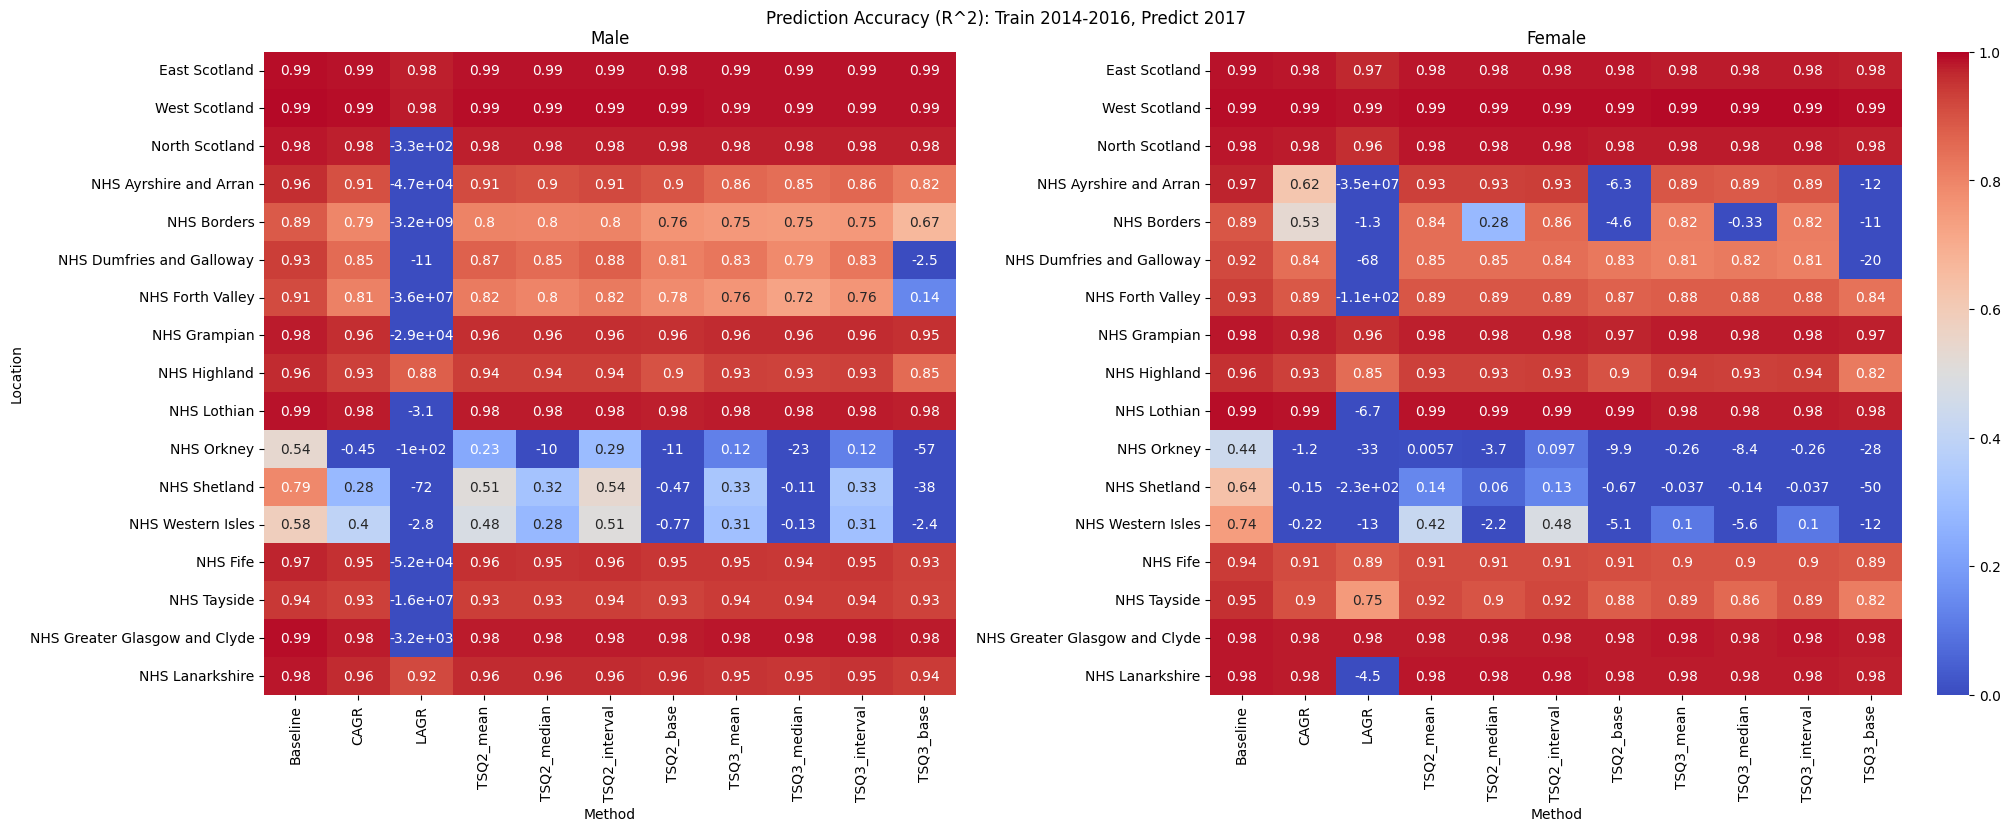

In [23]:
plot_accuracy_heatmap(
    accuracy_df,
    title=f"Prediction Accuracy (R^2): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

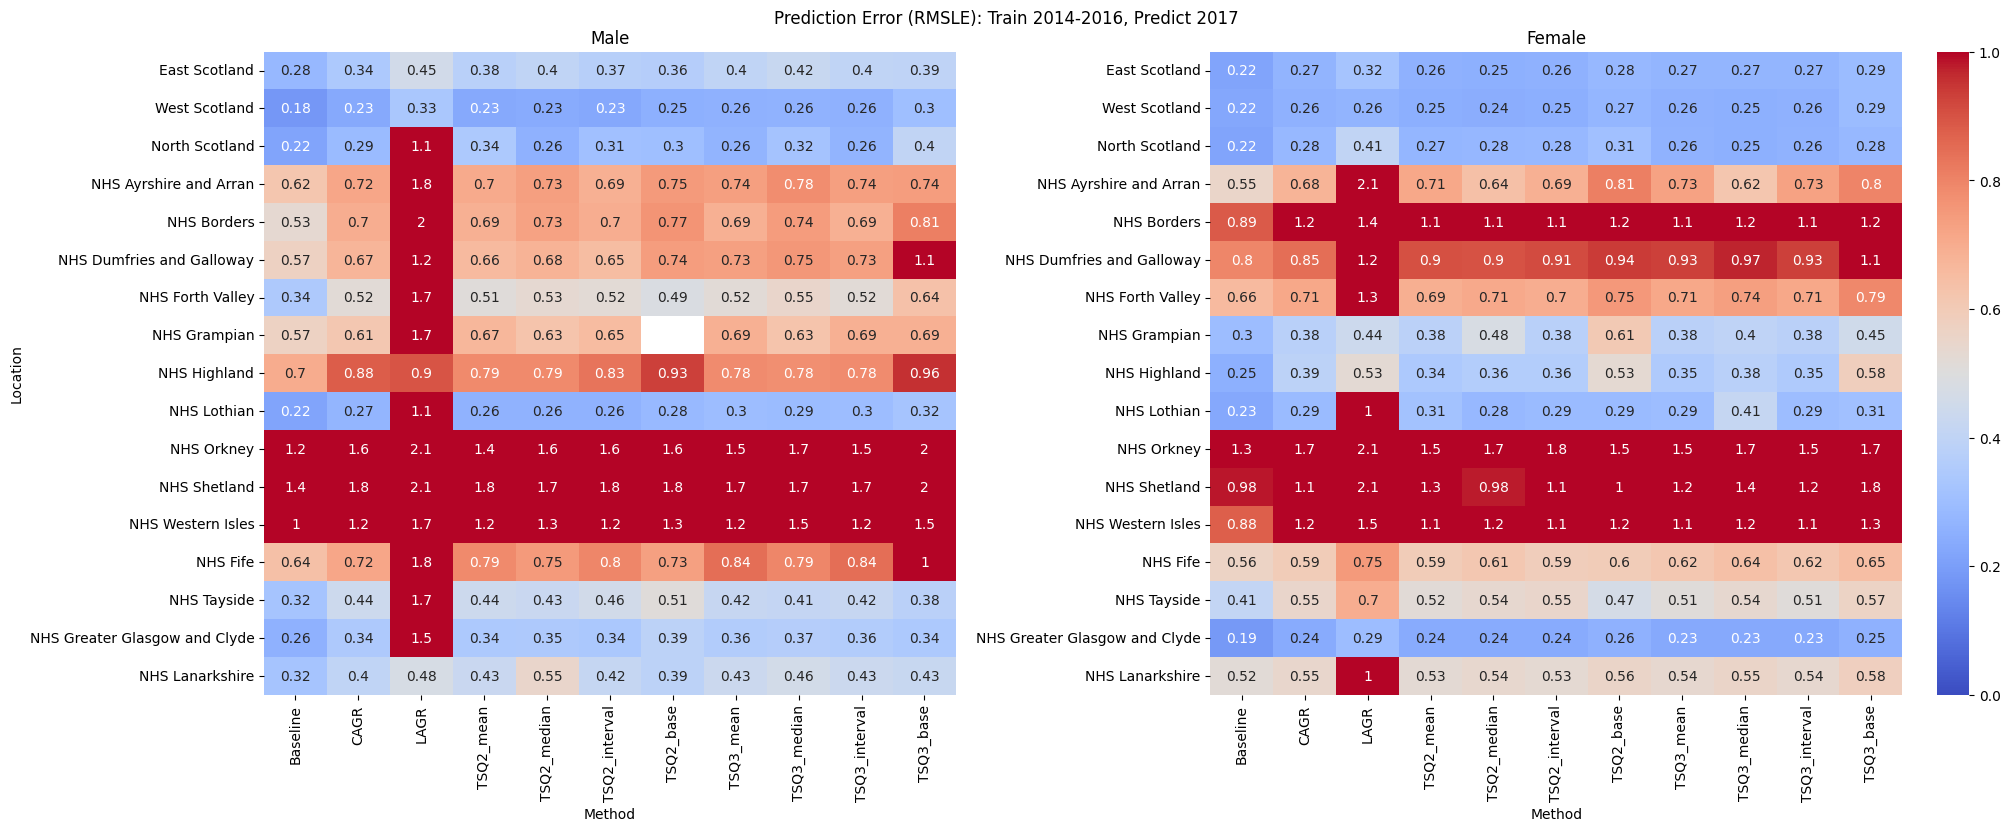

In [24]:
plot_accuracy_heatmap(
    rmsle_df,
    title=f"Prediction Error (RMSLE): Train 2014-{end_yr}, Predict {end_yr + 1}"
)

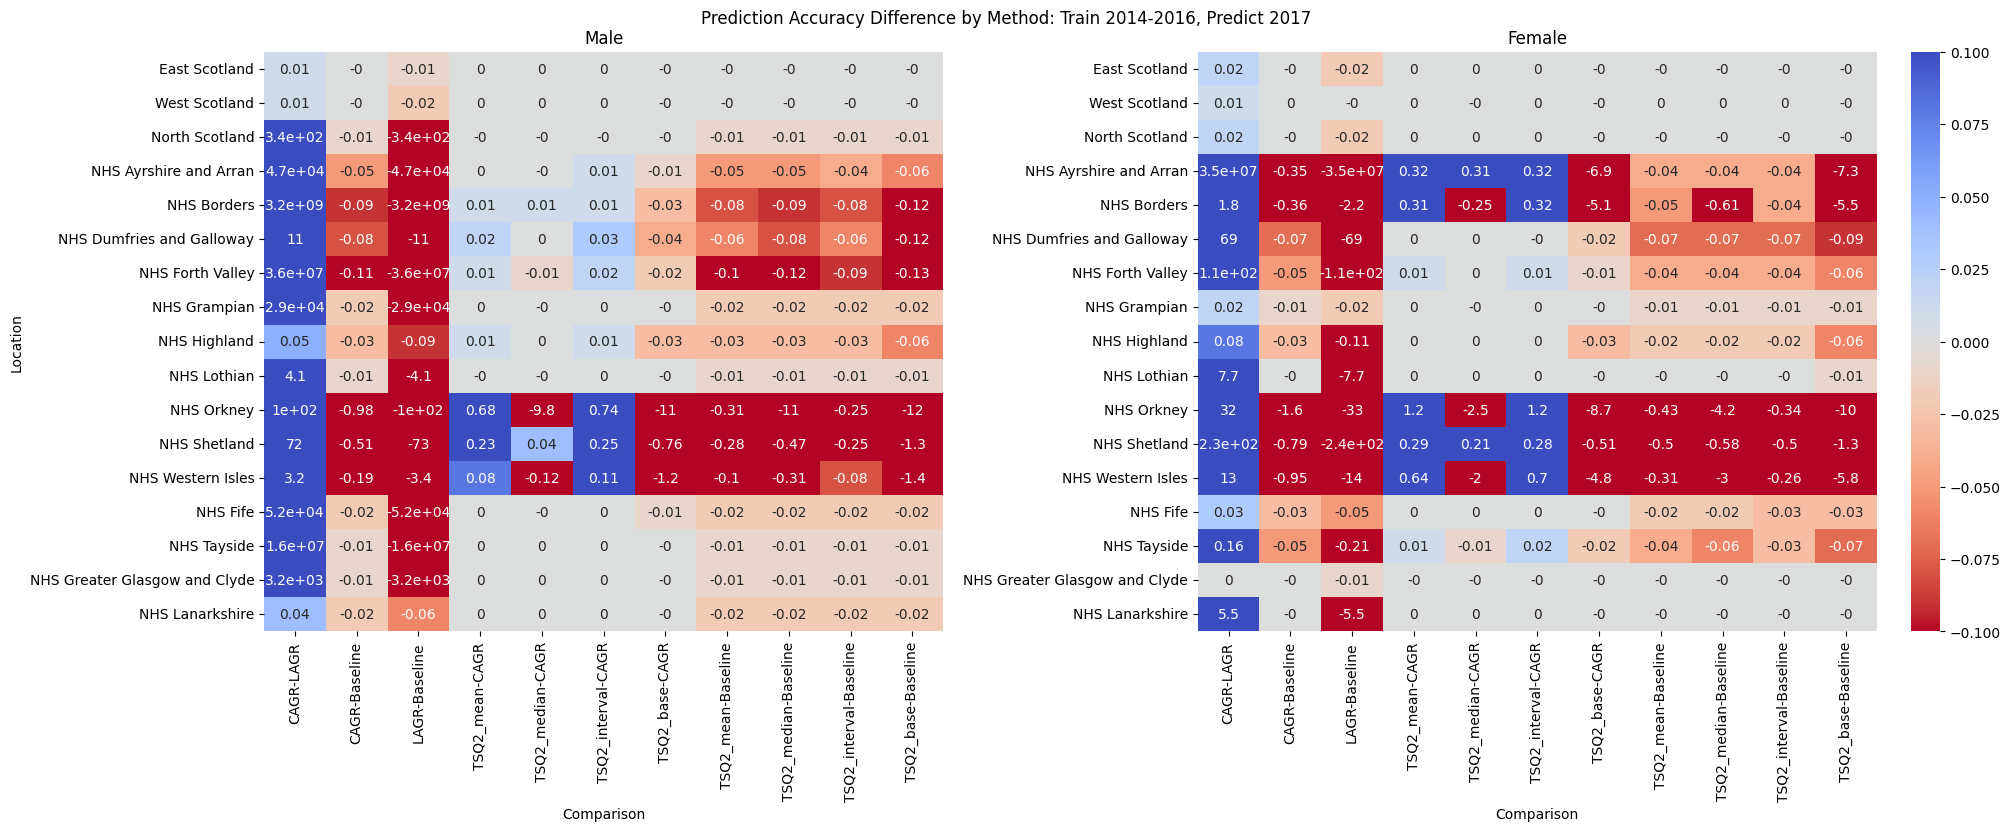

In [25]:
accuracy_comp_2016 = plot_comparison_heatmap(
    accuracy_df,
    title=f"Prediction Accuracy Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)

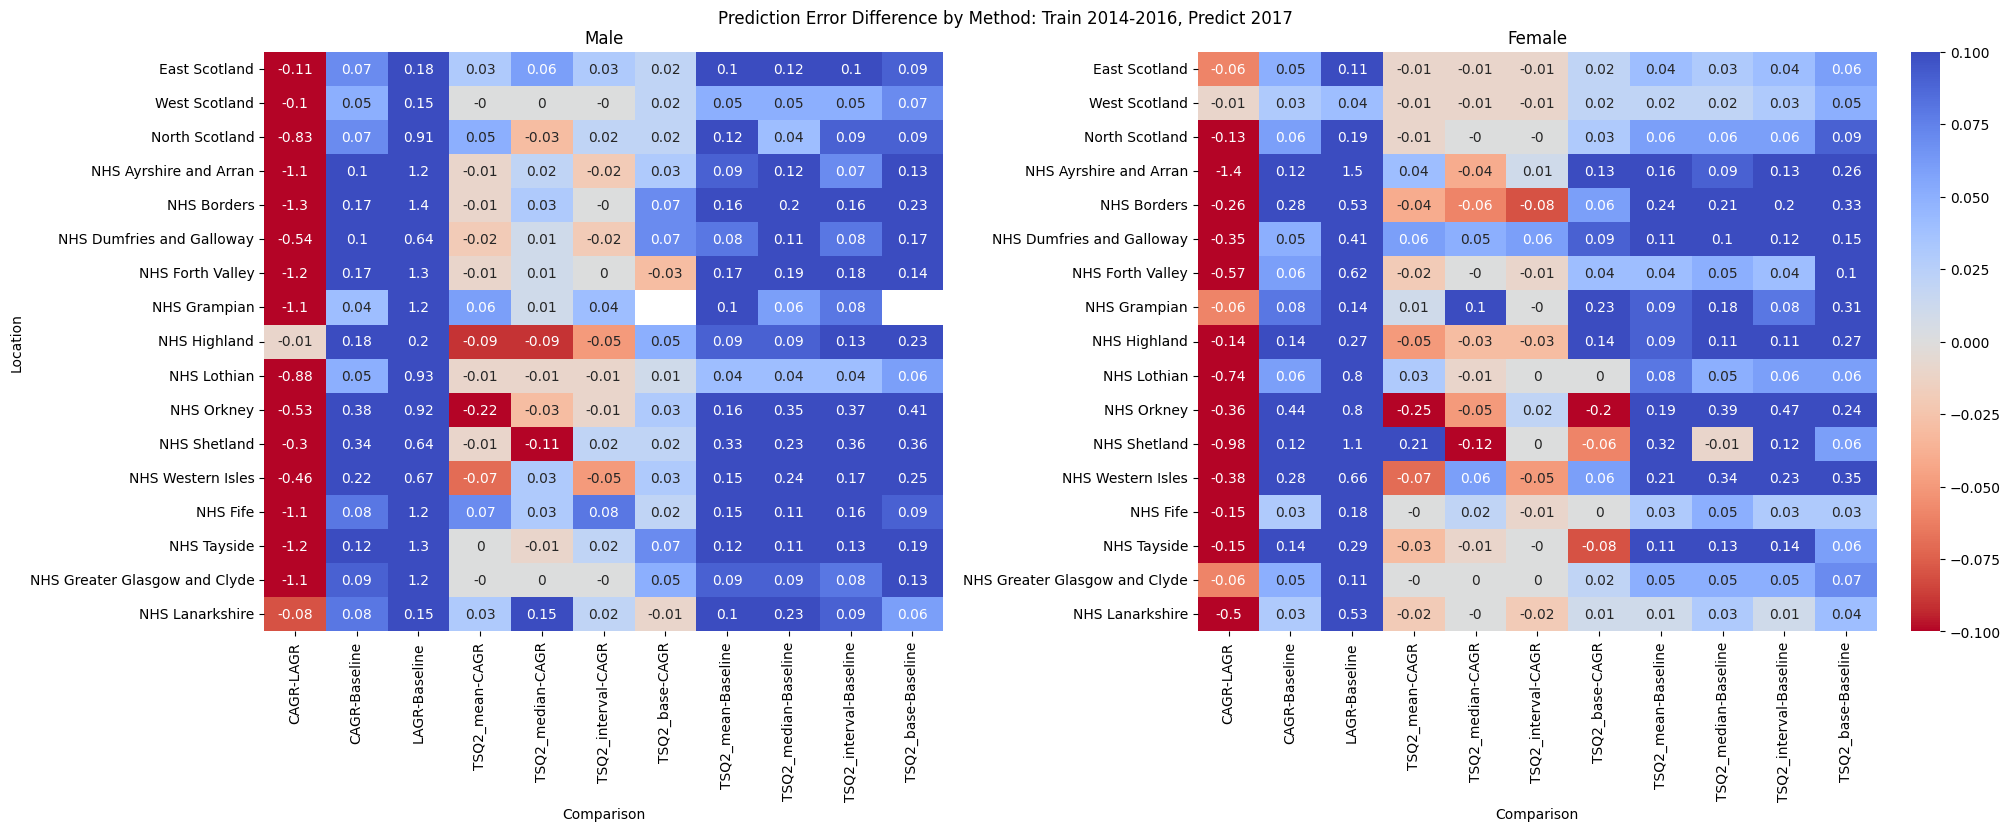

In [26]:
rmsle_comp_2016 = plot_comparison_heatmap(
    rmsle_df,
    title=f"Prediction Error Difference by Method: Train 2014-{end_yr}, Predict {end_yr + 1}"
)